# 3 — Logistic Regression

This chapter implements an **interpretable logistic regression model** for heart disease prediction. Logistic regression serves as the primary modelling approach because it is well suited for binary outcomes and allows direct interpretation through model coefficients.

The model uses all 12 clinical features (without `source_code`, see Chapter 5 for rationale). To reduce overfitting, **L1 regularization (LASSO)** is applied, which shrinks less informative coefficients towards zero.

## Focus: Minimising False Negatives

Since the model is intended as a **medical screening tool**, the most critical error is a **false negative** — predicting "no disease" when a patient actually has heart disease. We therefore analyse multiple classification thresholds to reduce false negatives while maintaining acceptable precision.

## Model Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| penalty | L1 | Feature selection via LASSO |
| solver | liblinear | Supports L1 regularization |
| max_iter | 1000 | Ensures convergence |

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"
MODELS  = "../results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue  (LogReg primary)
CLR_RED   = "#CA6B6E"   # muted rose
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "pres_blue", [CLR_GRAY, CLR_BLUE], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 3.1 — Data Loading & Preparation

In [2]:
df = load_processed_data()

print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print("\nTarget distribution:")
print(df["num"].value_counts().sort_index())


Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64


In [3]:
# All clinical features, without source_code
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")

Features: 12  (cont=5, bin=3, multi=4)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']


In [4]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 3.2 — Model Training & Cross-Validation

We build a pipeline (**ColumnTransformer → LogisticRegression**) with L1 regularization and evaluate it using **5-fold stratified cross-validation** on the training set.

- `penalty="l1"` works *inside* the model: it shrinks weak predictors towards zero.
- Cross-validation works *outside* the model: it estimates generalisation performance across data splits.

In [5]:
# Logistic regression model
LOGREG_PARAMS = dict(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(**LOGREG_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8757 ± 0.0248
Per fold:   [0.859  0.8402 0.9078 0.8736 0.8982]

Test ROC-AUC:  0.8895

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.80      0.74      0.77        82
     Disease       0.81      0.85      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



## 3.3 — Threshold Optimisation

The default threshold of 0.5 is not optimal for medical screening. The cost of errors is asymmetric:

- **False positives** are acceptable: they lead to an additional examination.
- **False negatives** are critical: a patient with heart disease remains undiagnosed.

We analyse classification thresholds from 0.5 down to 0.2 to identify a threshold that minimises false negatives while maintaining reasonable precision.

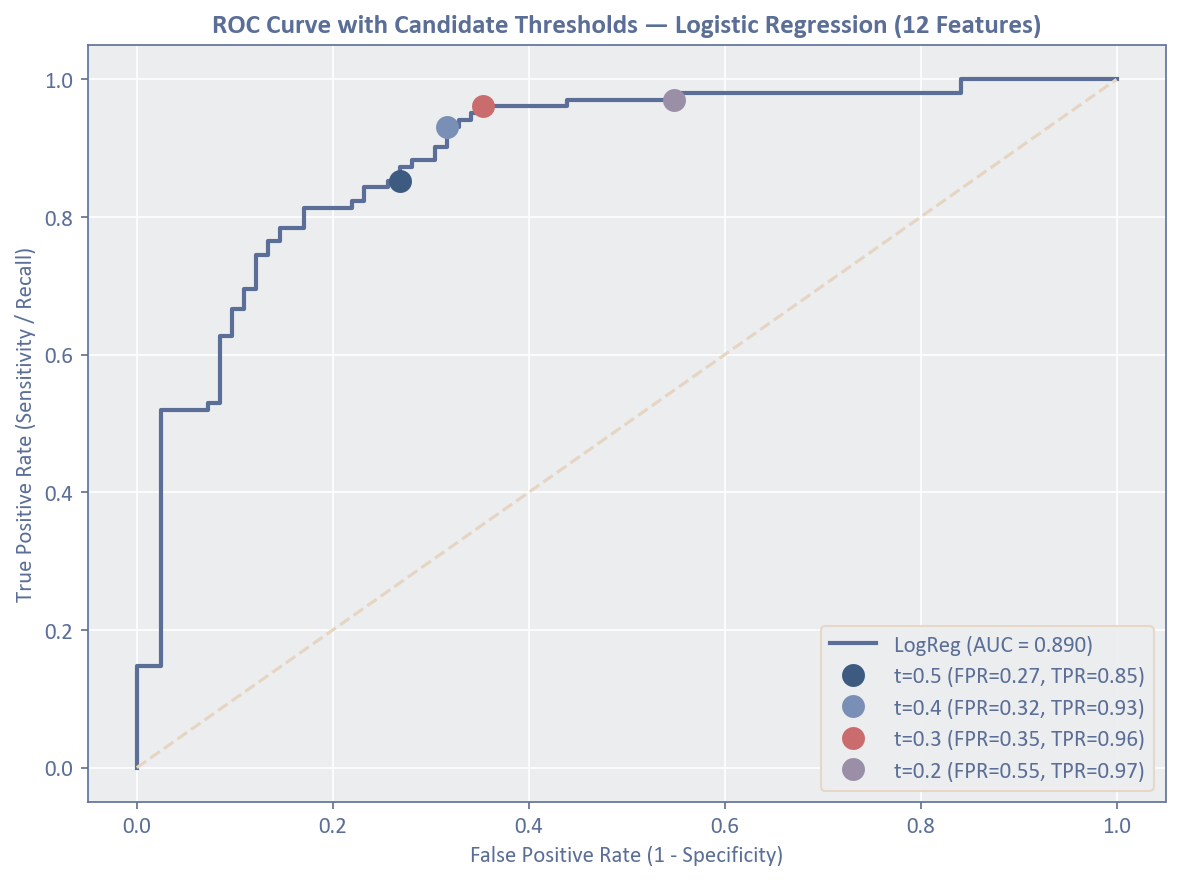

,threshold,precision,recall,f1,accuracy,specificity
0,0.5,0.805556,0.852941,0.828571,0.804348,0.743902
1,0.4,0.785124,0.931373,0.852018,0.820652,0.682927
2,0.3,0.759690,0.960784,0.848485,0.809783,0.621951
3,0.2,0.717391,0.970588,0.825000,0.771739,0.524390


In [6]:
# ROC curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=CLR_BLUE, lw=2, label=f"LogReg (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark candidate thresholds on the ROC curve
marker_colors = ["#3D5A80", "#7A8FB5", "#CA6B6E", "#9B8EA7"]
for thresh, color in zip(candidate_thresholds, marker_colors):
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(
        fpr[idx], tpr[idx], "o",
        color=color, markersize=10,
        label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})"
    )

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds \u2014 Logistic Regression (12 Features)")
ax.legend(loc="lower right")

fig.savefig(f"{FIGURES}/logreg_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

threshold_results = []

for thresh in candidate_thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    threshold_results.append({
        "threshold": thresh,
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh),
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "specificity": confusion_matrix(y_test, y_pred_thresh)[0, 0] /
                       confusion_matrix(y_test, y_pred_thresh)[0].sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

## 3.4 — Confusion Matrices at Different Thresholds

For each threshold, we visualise the confusion matrix. The critical cell is the **false negative (FN)** — a patient with disease predicted as "No Disease".

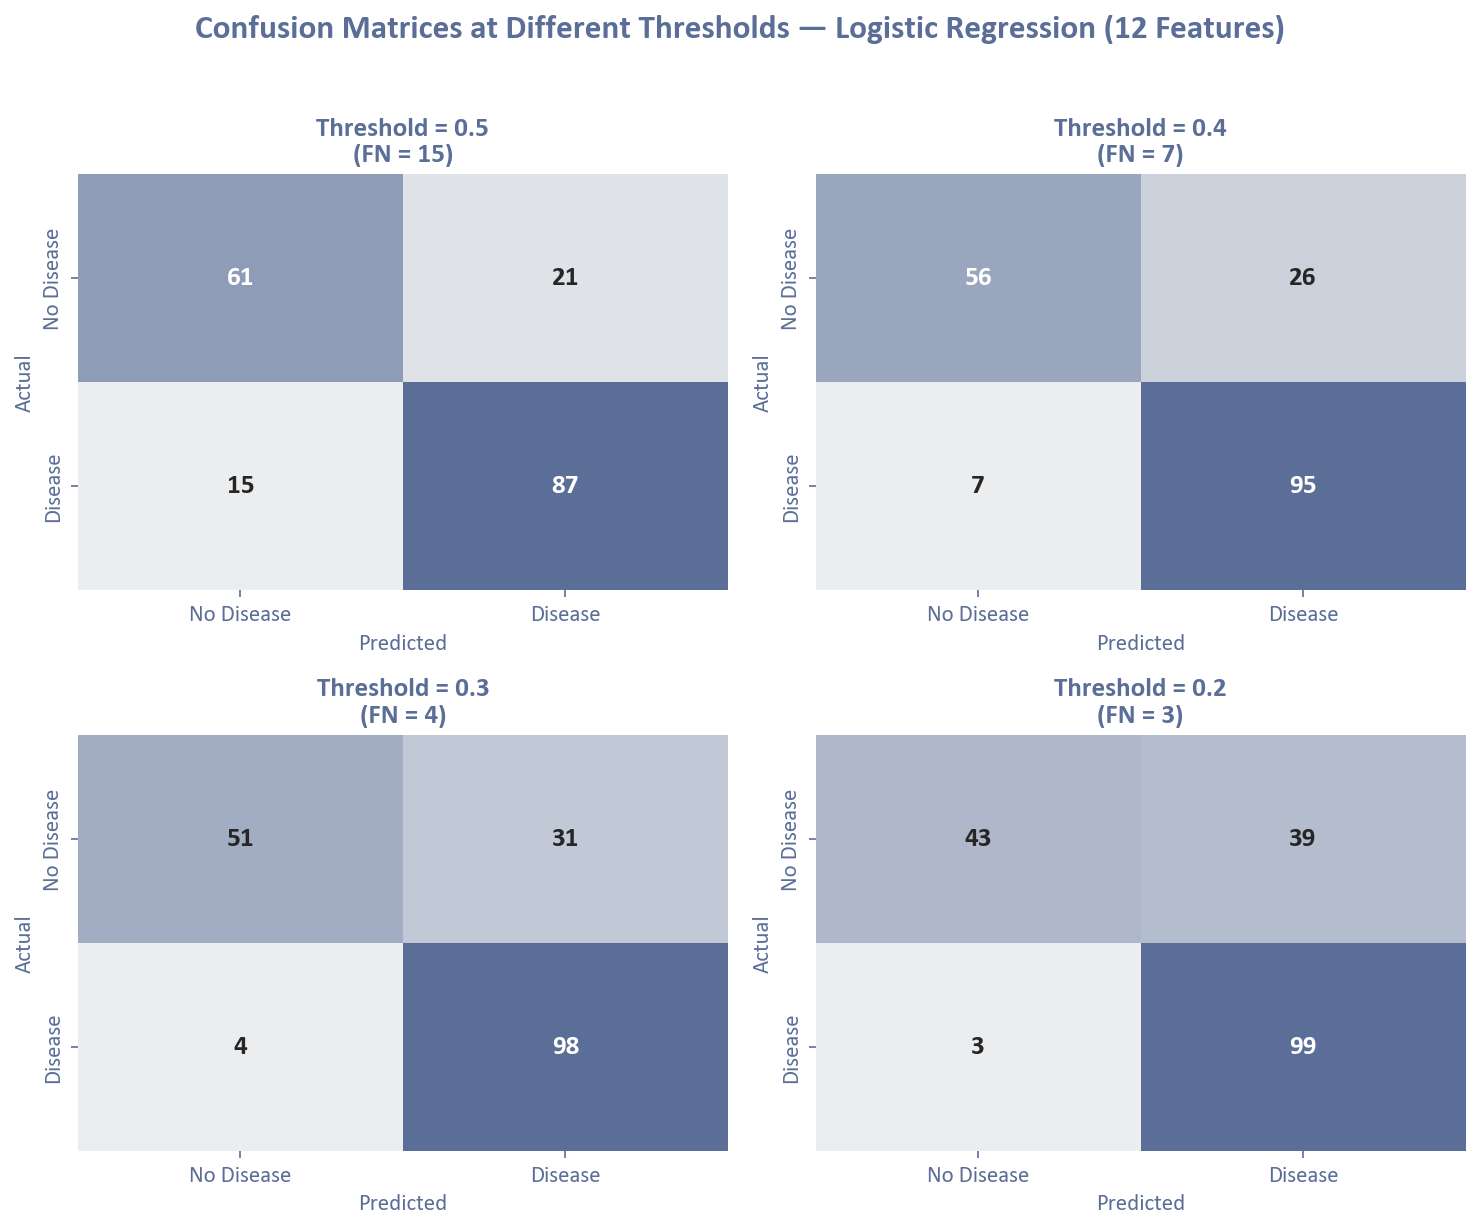

In [7]:
# Confusion matrices in 2x2 grid for all candidate thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=CMAP_BLUE,
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"],
        ax=axes[i],
        cbar=False,
        annot_kws={"fontsize": 13, "fontweight": "bold"},
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].grid(False)

    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds \u2014 Logistic Regression (12 Features)", fontsize=16, y=1.02, fontweight="bold")
fig.savefig(f"{FIGURES}/logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [8]:
# Detailed metrics comparison across thresholds
rows = []

for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Threshold": thresh,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/logreg_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,87,21,15,61,0.8043,0.8056,0.8529,0.7439,0.8286,0.1471
1,0.4,95,26,7,56,0.8207,0.7851,0.9314,0.6829,0.8520,0.0686
2,0.3,98,31,4,51,0.8098,0.7597,0.9608,0.6220,0.8485,0.0392
3,0.2,99,39,3,43,0.7717,0.7174,0.9706,0.5244,0.8250,0.0294


### Threshold Selection Rationale

The metrics illustrate the trade-off between false negatives and false positives:

- At **t = 0.5**: balanced performance (accuracy ~0.80, recall ~0.85), but **15 missed disease cases**.
- At **t = 0.4**: recall increases to ~0.93, reducing missed cases to 7.
- At **t = 0.3**: recall reaches ~0.96, with only **4 missed disease cases**. Specificity remains at ~0.62.
- At **t = 0.2**: marginal recall improvement (FN = 3), but specificity drops substantially.

**Selected threshold: 0.3** — it achieves high recall while maintaining acceptable specificity. For a screening tool, missing a disease case is far more critical than an unnecessary referral.

## 3.5 — Coefficient Interpretation & Feature Selection via L1

Each logistic regression coefficient indicates how a predictor influences the log-odds of the outcome. An odds ratio > 1 increases disease probability; < 1 is protective. Coefficients correspond to standardised continuous variables and one-hot encoded categoricals.

**L1 regularization as feature selection:** The L1 (LASSO) penalty applied during training shrinks weak predictors towards zero. Features that survive with large absolute coefficients are the most influential. By aggregating the absolute coefficients of one-hot encoded categories back to their original variable, we obtain a principled feature importance ranking. This ranking is used in Chapter 5 to build a reduced screening model based on the top 5 variables.

In [9]:
# Extract trained components from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

# Extract coefficients
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()


,feature,coefficient
0,age,0.292989
1,trestbps,-0.012430
2,chol,0.214378
3,thalach,-0.395584
4,oldpeak,0.476962


In [10]:
# Convert logistic regression coefficients to odds ratios and sort features by effect size
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df = coef_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

print("Top predictors increasing disease risk:\n")
coef_df.head(10)


Top predictors increasing disease risk:



,feature,coefficient,odds_ratio
0,sex,1.303963,3.683866
1,thal_7.0,0.994730,2.703994
2,cp_4.0,0.890453,2.436233
3,exang,0.770049,2.159872
4,thal_6.0,0.487239,1.627816
5,oldpeak,0.476962,1.611172
6,restecg_1.0,0.328607,1.389032
7,age,0.292989,1.340429
8,slope_2.0,0.239118,1.270129
9,chol,0.214378,1.239091


In [11]:
# Show features with the lowest odds ratios (strongest protective effects)
print("Top predictors decreasing disease risk:\n")
coef_df.sort_values("odds_ratio").head(10)


Top predictors decreasing disease risk:



,feature,coefficient,odds_ratio
16,cp_2.0,-1.247090,0.287340
15,thalach,-0.395584,0.673287
14,cp_3.0,-0.309274,0.733979
13,restecg_2.0,-0.196312,0.821756
12,trestbps,-0.012430,0.987647
11,slope_3.0,0.000000,1.000000
10,fbs,0.201404,1.223119
9,chol,0.214378,1.239091
8,slope_2.0,0.239118,1.270129
7,age,0.292989,1.340429


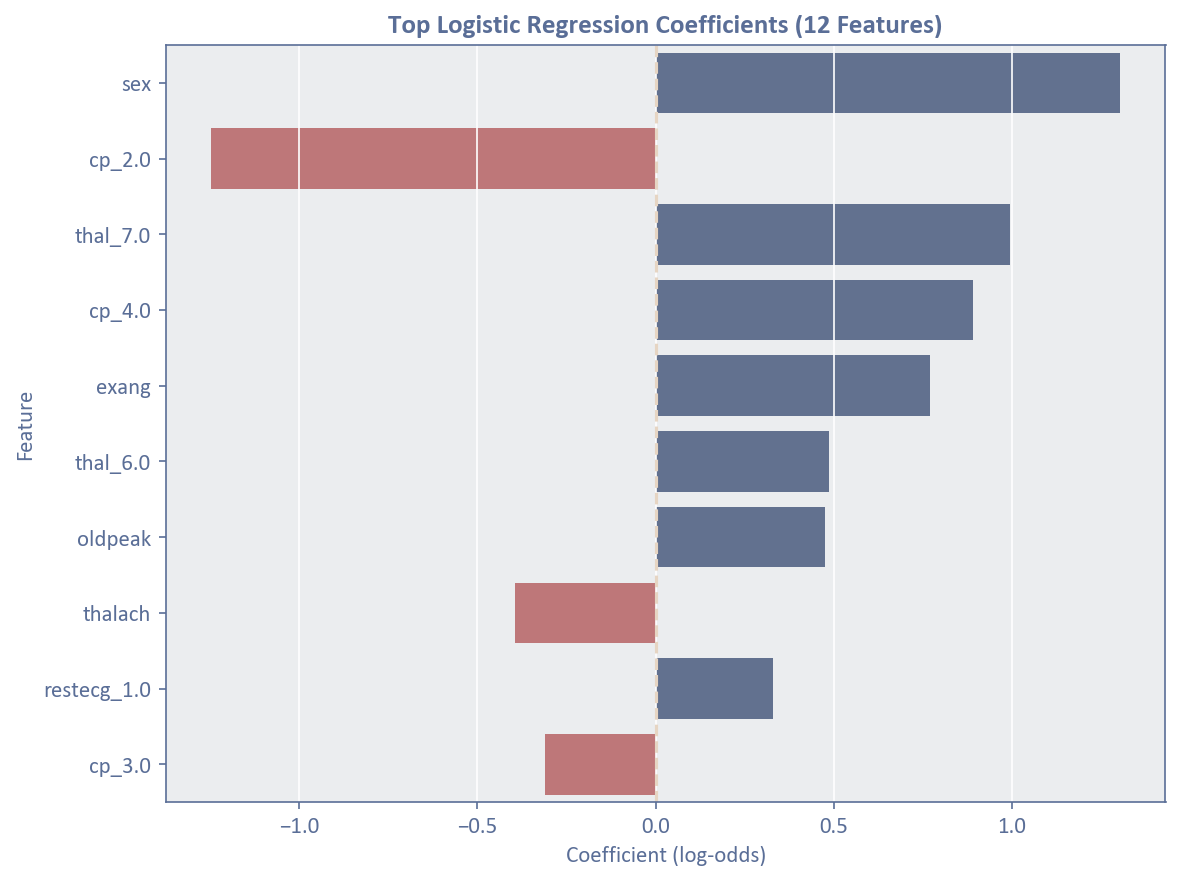

In [12]:
# Plot top coefficients
top = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [CLR_RED if v < 0 else CLR_BLUE for v in top["coefficient"]]
sns.barplot(
    data=top,
    y="feature",
    x="coefficient",
    palette=colors,
    ax=ax,
)

ax.axvline(0, color=CLR_BEIGE, linestyle="--", lw=1.5)
ax.set_title("Top Logistic Regression Coefficients (12 Features)")
ax.set_xlabel("Coefficient (log-odds)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(f"{FIGURES}/logreg_coefficients.png", dpi=150)
plt.show()

In [13]:
# Aggregate coefficients from one-hot encoded features back to their original variables
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}

for row in coef_df.itertuples():
    col = row.feature
    coef = abs(row.coefficient)

    original = col

    if col.startswith("source_"):
        original = "source_code"
    else:
        for name in _MULTICLASS_ORIGINALS:
            if col.startswith(name + "_"):
                original = name
                break

    if original not in original_importance:
        original_importance[original] = 0

    original_importance[original] += coef


importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["rank"] = range(1, len(importance_df)+1)

print("Feature ranking (aggregated |coefficients|):\n")
print(importance_df.to_string(index=False))

print("\n" + "=" * 50)
print("TOP 5 MOST INFLUENTIAL VARIABLES (Logistic Regression)")
print("=" * 50)
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']:15s}  (importance = {row['importance']:.4f})")


Feature ranking (aggregated |coefficients|):

 feature  importance  rank
      cp    2.446818     1
    thal    1.481969     2
     sex    1.303963     3
   exang    0.770049     4
 restecg    0.524919     5
 oldpeak    0.476962     6
 thalach    0.395584     7
     age    0.292989     8
   slope    0.239118     9
    chol    0.214378    10
     fbs    0.201404    11
trestbps    0.012430    12

TOP 5 MOST INFLUENTIAL VARIABLES (Logistic Regression)
  1. cp               (importance = 2.4468)
  2. thal             (importance = 1.4820)
  3. sex              (importance = 1.3040)
  4. exang            (importance = 0.7700)
  5. restecg          (importance = 0.5249)


### Feature Selection Method

The top 5 variables were identified by aggregating the absolute L1-regularized coefficients back to their original variable names. This is **embedded feature selection** — the L1 penalty naturally shrinks uninformative predictors towards zero during training, so the remaining coefficient magnitudes reflect each feature's importance.

This approach differs from **Recursive Feature Elimination (RFE)**, which iteratively removes features and retrains the model. L1 selection is computationally simpler and well-suited for logistic regression.

**Caveat:** The feature ranking was computed on the full training set, not inside cross-validation folds. This means the selected features may be slightly optimistic. A more rigorous approach (RFECV) is discussed in the outlook (Chapter 5).

## 3.6 — Model Persistence & Summary

In [14]:
# Save model for reuse in Chapter 5
model_path = f"{MODELS}/logreg_model.joblib"
joblib.dump(pipe, model_path)

# Summary at selected threshold (t=0.3)
t = 0.3
y_pred_t = (y_prob >= t).astype(int)
cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("LOGISTIC REGRESSION — FINAL RESULTS (all clinical features)")
print("=" * 60)
print(f"\nFeatures:         {X.shape[1]} (without source_code)")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Test ROC-AUC:     {test_auc:.4f}")
print(f"\nAt threshold t = {t}:")
print(f"  Sensitivity:    {recall_score(y_test, y_pred_t):.4f}")
print(f"  Precision:      {precision_score(y_test, y_pred_t):.4f}")
print(f"  Accuracy:       {accuracy_score(y_test, y_pred_t):.4f}")
print(f"  Specificity:    {tn / (tn + fp):.4f}")
print(f"  FN:             {fn}")
print(f"  FP:             {fp}")
print(f"\nTop 5 variables:")
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']}")
print(f"\nModel saved to: {model_path}")

LOGISTIC REGRESSION — FINAL RESULTS (all clinical features)

Features:         12 (without source_code)
CV ROC-AUC:       0.8757 +/- 0.0248
Test ROC-AUC:     0.8895

At threshold t = 0.3:
  Sensitivity:    0.9608
  Precision:      0.7597
  Accuracy:       0.8098
  Specificity:    0.6220
  FN:             4
  FP:             31

Top 5 variables:
  1. cp
  2. thal
  3. sex
  4. exang
  5. restecg

Model saved to: ../results/models/logreg_model.joblib
